## Imports & Global Configuration

In [1]:
import random
import json
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Tuple, Dict, Any, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
from PIL import Image
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import torch.nn.functional as F

import warnings
warnings.filterwarnings("ignore")

print("✅ Imports OK")
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())


# --- Configuration Class ---
@dataclass
class Config:
    """Experiment configuration for image-based TB classification."""
    # Paths
    data_dir: str = "../../Data/spec_overall/"
    output_dir: str = "./output"
    
    # Reproducibility
    seed: int = 42
    
    # Data splits (5-fold subject-level SKF + inner train/val split per fold)
    n_runs: int = 5
    # 0.25 * 0.80 = val 0.20 of total subjects per fold
    run_val_size: float = 0.25
    
    # Training hyperparameters
    batch_size: int = 8
    epochs: int = 50
    learning_rate: float = 1e-4
    weight_decay: float = 0
    
    # Early stopping
    early_stop_patience: int = 10
    early_stop_min_delta: float = 0.0005
    
    # Scheduler
    scheduler_factor: float = 0.5
    scheduler_patience: int = 5
    min_lr: float = 1e-7
    
    # Threshold policy
    target_sensitivity: float = 0.90
    
    # Image parameters
    img_size: Tuple[int, int] = (224, 224)
    channels: str = "RGB"
    
    # Loss parameters
    pos_weight: float = 2.0
    
    # Oversampling
    train_oversample_factor: int = 1
    sampler_balance: bool = True
    keep_pos_weight_with_sampler: bool = False
    
    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Transforms
    train_transform: Any = None
    val_transform: Any = None
    
    def __post_init__(self):
        Path(self.output_dir).mkdir(parents=True, exist_ok=True)
        self._set_seed()
        self._setup_transforms()
    
    def _set_seed(self):
        random.seed(self.seed)
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)
        torch.cuda.manual_seed_all(self.seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    
    def _setup_transforms(self):
        self.train_transform = transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
        
        self.val_transform = transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
    
    def save(self, path: str):
        with open(path, 'w') as f:
            json.dump(asdict(self), f, indent=2)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Initialize Config
config = Config()
set_seed(config.seed)

print("\n✅ Config ready (5-fold subject-level SKF)")
print(config)
print(f"\nDevice: {config.device}")
print(f"Number of folds: {config.n_runs}")
print(f"Inner val size per fold: {config.run_val_size*100}% of train_val")

✅ Imports OK
torch: 2.11.0+cpu
cuda: False

✅ Config ready (5-fold subject-level SKF)
Config(data_dir='../../Data/spec_overall/', output_dir='./output', seed=42, n_runs=5, run_val_size=0.25, batch_size=8, epochs=50, learning_rate=0.0001, weight_decay=0, early_stop_patience=10, early_stop_min_delta=0.0005, scheduler_factor=0.5, scheduler_patience=5, min_lr=1e-07, target_sensitivity=0.9, img_size=(224, 224), channels='RGB', pos_weight=2.0, train_oversample_factor=1, sampler_balance=True, keep_pos_weight_with_sampler=False, device='cpu', train_transform=Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
), val_transform=Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
))

Device: cpu
Number of folds: 5
Inner val size per fold: 25.0% of train_val


## Dataset & Model Classes


In [2]:

# Custom Dataset
class CustomImageDataset(Dataset):
    """Dataset for loading spectrogram images"""
    def __init__(self, df: pd.DataFrame, transform=None, channels="RGB"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.channels = channels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert(self.channels)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row["label"], dtype=torch.float32)
        return img, label

class TB_CNN(nn.Module):
    """2D CNN from CNN_paper.py with stride-2 conv blocks."""
    def __init__(self, num_classes=1, channels="RGB"):
        super().__init__()
        in_channels = 3 if channels == "RGB" else 1

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=5, stride=2, padding=2),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_channels),
                nn.Dropout2d(p=0.25)
            )

        self.features = nn.Sequential(
            conv_block(in_channels, 8),
            conv_block(8, 16),
            conv_block(16, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

print("✅ CustomImageDataset and TB_CNN defined")

✅ CustomImageDataset and TB_CNN defined


## Data Loader

In [3]:
# Data Loading (same as reference notebook)
import re


def parse_subject_id_from_name(fname: str) -> str:
    """Extract subject_id from filename (3 digits pattern)"""
    m = re.match(r"^(\d{3})_", fname)
    if not m:
        raise ValueError(f"Filename does not match pattern ^(\\d{{3}})_: {fname}")
    return m.group(1)

def build_df_from_spec_overall(data_root: str) -> pd.DataFrame:
    """Build dataframe from spec_overall folder structure"""
    root = Path(data_root)
    rows = []

    for cls_name, label in [("PTB", 1), ("Healthy", 0)]:
        folder = root / cls_name
        if not folder.exists():
            raise FileNotFoundError(f"Missing folder: {folder}")

        img_files = []
        for ext in ("*.png", "*.jpg", "*.jpeg"):
            img_files += list(folder.rglob(ext))

        for p in img_files:
            sid = parse_subject_id_from_name(p.name)
            rows.append({
                "image_path": str(p),
                "label": int(label),
                "subject_id": sid,
                "file_name": p.name,
            })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise ValueError("No images found. Check PTB/Healthy folders.")

    df["subject_id"] = df["subject_id"].astype(str)
    df["label"] = df["label"].astype(int)

    print("✅ df built from spectrograms")
    print(f"Total samples: {len(df)}")
    print("Label counts:\n", df["label"].value_counts())
    print(f"Unique subjects: {df['subject_id'].nunique()}")
    return df

df_metadata = build_df_from_spec_overall(config.data_dir)
df_metadata.head()

✅ df built from spectrograms
Total samples: 512
Label counts:
 label
0    325
1    187
Name: count, dtype: int64
Unique subjects: 15


,image_path,label,subject_id,file_name
0,..\..\Data\spec_overall\PTB\006_01_seg_01_spec...,1,006,006_01_seg_01_spectrogram.png
1,..\..\Data\spec_overall\PTB\006_01_seg_02_spec...,1,006,006_01_seg_02_spectrogram.png
2,..\..\Data\spec_overall\PTB\006_01_seg_03_spec...,1,006,006_01_seg_03_spectrogram.png
3,..\..\Data\spec_overall\PTB\006_01_seg_04_spec...,1,006,006_01_seg_04_spectrogram.png
4,..\..\Data\spec_overall\PTB\006_01_seg_05_spec...,1,006,006_01_seg_05_spectrogram.png


## Fold Splitter Class

In [4]:
# Subject-level 5-fold StratifiedKFold with inner train/val split (SI-style)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit


def build_subject_table_from_df(df: pd.DataFrame) -> pd.DataFrame:
    """Build subject-level table aggregated by mode of labels"""
    tmp = df.copy()
    tmp["subject_id"] = tmp["subject_id"].astype(str)
    tmp["label"] = tmp["label"].astype(int)

    def mode_int(x):
        vc = x.value_counts()
        return int(vc.idxmax())

    st = (
        tmp.groupby("subject_id")["label"]
        .apply(mode_int)
        .reset_index()
        .rename(columns={"label": "subject_label"})
        .sort_values("subject_id")
        .reset_index(drop=True)
    )
    return st


def filter_by_subjects(df: pd.DataFrame, subject_ids: np.ndarray) -> pd.DataFrame:
    return df[df["subject_id"].isin(set(subject_ids))].reset_index(drop=True)


def print_detailed_stats(df_meta: pd.DataFrame, subj_ids, split_name: str, total_n: int):
    df_subset = df_meta[df_meta["subject_id"].isin(subj_ids)]
    ptb_df = df_subset[df_subset["label"] == 1]
    nontb_df = df_subset[df_subset["label"] == 0]
    ptb_subjs = sorted([str(s) for s in ptb_df["subject_id"].unique()])
    nontb_subjs = sorted([str(s) for s in nontb_df["subject_id"].unique()])
    ptb_segments = len(ptb_df)
    nontb_segments = len(nontb_df)
    ratio = len(subj_ids) / total_n
    print(f"{split_name.upper()} SET: {len(subj_ids)} subjects ({ratio:.2%})")
    print(f"   ├─ PTB (1)    : {ptb_segments:>4} Segments | IDs: {', '.join(ptb_subjs)}")
    print(f"   └─ Healthy (0): {nontb_segments:>4} Segments | IDs: {', '.join(nontb_subjs)}")


def build_cv_fold(
    df_samples: pd.DataFrame,
    n_runs: int = 5,
    # 0.25 * 0.80 = val 0.20 of total subjects per fold
    run_val_size: float = 0.25,
    random_seed: int = 42
):
    print(f"\n{'='*80}")
    print(f"SUBJECT-LEVEL SKF on spectrogram: {n_runs}-FOLD (with fold-specific test)")
    print(f"{'='*80}")

    st = build_subject_table_from_df(df_samples)
    X_subj = st["subject_id"].values
    y_subj = st["subject_label"].values

    # Sanity check: each subject must map to exactly one class
    assert df_samples.groupby("subject_id")["label"].nunique().max() == 1, \
        "Subject has multiple labels - check your data!"

    outer_skf = StratifiedKFold(n_splits=n_runs, shuffle=True, random_state=random_seed)
    all_fold_splits = []

    for fold, (train_val_idx, test_idx) in enumerate(outer_skf.split(X_subj, y_subj), start=1):
        train_val_subj = X_subj[train_val_idx]
        y_train_val = y_subj[train_val_idx]
        test_subj = X_subj[test_idx]

        inner_split = StratifiedShuffleSplit(
            n_splits=1,
            test_size=run_val_size,
            random_state=random_seed + fold
        )
        inner_train_idx, inner_val_idx = next(inner_split.split(train_val_subj, y_train_val))
        train_subj_ids = train_val_subj[inner_train_idx]
        val_subj_ids = train_val_subj[inner_val_idx]

        train_subj_set = set(train_subj_ids.tolist())
        val_subj_set = set(val_subj_ids.tolist())
        test_subj_set = set(test_subj.tolist())

        assert train_subj_set.isdisjoint(val_subj_set), f"Fold {fold}: train/val overlap!"
        assert train_subj_set.isdisjoint(test_subj_set), f"Fold {fold}: train/test overlap!"
        assert val_subj_set.isdisjoint(test_subj_set), f"Fold {fold}: val/test overlap!"

        run_train_df = filter_by_subjects(df_samples, train_subj_ids)
        run_val_df = filter_by_subjects(df_samples, val_subj_ids)
        run_test_df = filter_by_subjects(df_samples, test_subj)

        all_fold_splits.append({
            "run": int(fold),
            "fold": int(fold),
            "train_subjects": sorted([str(s) for s in train_subj_ids.tolist()]),
            "val_subjects": sorted([str(s) for s in val_subj_ids.tolist()]),
            "test_subjects": sorted([str(s) for s in test_subj.tolist()]),
            "df_train": run_train_df,
            "df_val": run_val_df,
            "df_test": run_test_df,
            "seed": random_seed + fold,
        })

        n_total = len(X_subj)
        print(f"\n--- Fold {fold} ---")
        print_detailed_stats(df_samples, train_subj_set, "Train", n_total)
        print_detailed_stats(df_samples, val_subj_set, "Val", n_total)
        print_detailed_stats(df_samples, test_subj_set, "Test", n_total)

    print(f"\n{'='*80}")
    print("NO SUBJECT LEAKAGE")
    print(f"{'='*80}\n")

    return {
        "subject_table": st,
        "runs": all_fold_splits,
    }


split_info = build_cv_fold(
    df_samples=df_metadata,
    n_runs=config.n_runs,
    run_val_size=config.run_val_size,
    random_seed=config.seed,
)


SUBJECT-LEVEL SKF on spectrogram: 5-FOLD (with fold-specific test)

--- Fold 1 ---
TRAIN SET: 9 subjects (60.00%)
   ├─ PTB (1)    :  125 Segments | IDs: 006, 009, 011, 015, 016
   └─ Healthy (0):  133 Segments | IDs: 005, 007, 013, 014
VAL SET: 3 subjects (20.00%)
   ├─ PTB (1)    :   20 Segments | IDs: 012
   └─ Healthy (0):  150 Segments | IDs: 002, 004
TEST SET: 3 subjects (20.00%)
   ├─ PTB (1)    :   42 Segments | IDs: 008
   └─ Healthy (0):   42 Segments | IDs: 001, 003

--- Fold 2 ---
TRAIN SET: 9 subjects (60.00%)
   ├─ PTB (1)    :  149 Segments | IDs: 006, 008, 009, 012, 016
   └─ Healthy (0):  103 Segments | IDs: 001, 003, 007, 014
VAL SET: 3 subjects (20.00%)
   ├─ PTB (1)    :    1 Segments | IDs: 011
   └─ Healthy (0):  150 Segments | IDs: 002, 004
TEST SET: 3 subjects (20.00%)
   ├─ PTB (1)    :   37 Segments | IDs: 015
   └─ Healthy (0):   72 Segments | IDs: 005, 013

--- Fold 3 ---
TRAIN SET: 9 subjects (60.00%)
   ├─ PTB (1)    :  129 Segments | IDs: 006, 008, 009, 

## Fold Check

In [5]:
# Final check - print train/val/test subject IDs per fold + leakage checks

def print_patient_ids(split_info, show_sorted=True):
    def _fmt(lst):
        lst = [str(x) for x in lst]
        return sorted(lst) if show_sorted else lst

    print("\n" + "=" * 90)
    print("PATIENT ID LISTS (subject_id) - 5-FOLD SUBJECT-LEVEL SKF")
    print("=" * 90)

    all_test_subjects = []

    for r in split_info["runs"]:
        fold_id = r["run"]
        tr = _fmt(r["train_subjects"])
        va = _fmt(r["val_subjects"])
        te = _fmt(r["test_subjects"])
        all_test_subjects.extend(te)

        inter_tr_va = set(tr) & set(va)
        inter_tr_te = set(tr) & set(te)
        inter_va_te = set(va) & set(te)

        print("\n" + "-" * 90)
        print(f"Fold {fold_id}")
        print(f"- Train subjects ({len(tr)}): {tr}")
        print(f"- Val   subjects ({len(va)}): {va}")
        print(f"- Test  subjects ({len(te)}): {te}")
        print(f"- Leakage check Train∩Val: {sorted(list(inter_tr_va))}  {'OK' if len(inter_tr_va) == 0 else 'FAIL'}")
        print(f"- Leakage check Train∩Test: {sorted(list(inter_tr_te))}  {'OK' if len(inter_tr_te) == 0 else 'FAIL'}")
        print(f"- Leakage check Val∩Test: {sorted(list(inter_va_te))}  {'OK' if len(inter_va_te) == 0 else 'FAIL'}")

    # Across-fold test partition check: each subject should appear in test exactly once
    unique_test = set(all_test_subjects)
    print("\n" + "=" * 90)
    print(f"Total test assignments: {len(all_test_subjects)}")
    print(f"Unique test subjects  : {len(unique_test)}")
    print(f"Duplicate test IDs    : {sorted([sid for sid in unique_test if all_test_subjects.count(sid) > 1])}")
    print("Cross-fold test coverage check:", "OK" if len(all_test_subjects) == len(unique_test) else "CHECK")

print_patient_ids(split_info, show_sorted=True)


PATIENT ID LISTS (subject_id) - 5-FOLD SUBJECT-LEVEL SKF

------------------------------------------------------------------------------------------
Fold 1
- Train subjects (9): ['005', '006', '007', '009', '011', '013', '014', '015', '016']
- Val   subjects (3): ['002', '004', '012']
- Test  subjects (3): ['001', '003', '008']
- Leakage check Train∩Val: []  OK
- Leakage check Train∩Test: []  OK
- Leakage check Val∩Test: []  OK

------------------------------------------------------------------------------------------
Fold 2
- Train subjects (9): ['001', '003', '006', '007', '008', '009', '012', '014', '016']
- Val   subjects (3): ['002', '004', '011']
- Test  subjects (3): ['005', '013', '015']
- Leakage check Train∩Val: []  OK
- Leakage check Train∩Test: []  OK
- Leakage check Val∩Test: []  OK

------------------------------------------------------------------------------------------
Fold 3
- Train subjects (9): ['001', '003', '004', '006', '008', '009', '013', '014', '016']
- Val  

## Early Stopping & Threshold Selector

In [6]:
# Early Stopping & Threshold Selector (same as reference)

import copy


class EarlyStopperAudioLike:
    """Early stopping with best state tracking"""
    def __init__(self, patience: int = 10, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_loss = float("inf")
        self.bad_epochs = 0
        self.best_state = None
        self.best_epoch = 0

    def step(self, val_loss: float, model: nn.Module, epoch: int) -> bool:
        """Returns True if should stop"""
        if val_loss < (self.best_val_loss - self.min_delta):
            self.best_val_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1

        if self.bad_epochs >= self.patience:
            return True
        return False

    def restore(self, model: nn.Module):
        """Restore best weights"""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

class ThresholdSelector:
    """Select threshold by maximizing Youden's J statistic (Sensitivity + Specificity - 1)."""
    def __init__(self):
        pass

    def find_threshold(self, y_true: np.ndarray, scores: np.ndarray):
        """Returns (threshold, metrics_dict)."""
        fpr, tpr, thresholds = roc_curve(y_true, scores)

        # Exclude inf threshold so the selected value is directly usable for score >= threshold.
        valid = np.isfinite(thresholds)
        if np.any(valid):
            fpr = fpr[valid]
            tpr = tpr[valid]
            thresholds = thresholds[valid]

        if len(thresholds) == 0:
            best_thr = 0.5
            best_j = 0.0
        else:
            youden_j = tpr - fpr
            best_idx = int(np.argmax(youden_j))
            best_thr = float(thresholds[best_idx])
            best_j = float(youden_j[best_idx])

        # Calculate final metrics at selected threshold
        y_pred = (scores >= best_thr).astype(int)
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        tp = np.sum((y_true == 1) & (y_pred == 1))

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        return best_thr, {
            "threshold": float(best_thr),
            "youden_j": float(best_j),
            "sensitivity": float(sensitivity),
            "specificity": float(specificity),
            "TP": int(tp),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
        }

print("✅ Early Stopping & Threshold Selector classes defined")

✅ Early Stopping & Threshold Selector classes defined


In [7]:
# Training Loop (with oversampling support)
def train_model(
    model: nn.Module,
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    config,
    device,
):
    """
    Train model with early stopping, optional oversampling, 
    BCEWithLogitsLoss with pos_weight, ReduceLROnPlateau scheduler.
    Returns (model, history, best_epoch, best_val_loss).
    """
    # Datasets
    train_dataset = CustomImageDataset(
        df_train, 
        transform=config.train_transform,
        channels=config.channels
    )
    val_dataset = CustomImageDataset(
        df_val, 
        transform=config.val_transform,
        channels=config.channels
    )

    # Sampler setup (oversampling if enabled)
    if config.sampler_balance:
        train_labels = df_train["label"].values
        class_counts = np.bincount(train_labels)
        
        if config.train_oversample_factor > 1:
            # Oversample minority class
            weights = np.zeros(len(train_labels))
            weights[train_labels == 0] = 1.0 / class_counts[0]
            weights[train_labels == 1] = (1.0 / class_counts[1]) * config.train_oversample_factor
        else:
            weights = np.array([1.0 / class_counts[lbl] for lbl in train_labels])
        
        sampler = WeightedRandomSampler(
            weights=torch.from_numpy(weights).double(),
            num_samples=len(weights),
            replacement=True
        )
        train_loader = DataLoader(train_dataset, batch_size=config.batch_size, sampler=sampler)
    else:
        train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)

    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

    # Loss with pos_weight
    pos_weight = torch.tensor([config.pos_weight], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Optimizer & Scheduler
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=config.scheduler_factor,
        patience=config.scheduler_patience,
        min_lr=config.min_lr,
    )

    # Early stopper
    early_stopper = EarlyStopperAudioLike(
        patience=config.early_stop_patience,
        min_delta=config.early_stop_min_delta
    )

    # Training loop
    history = {"train_loss": [], "val_loss": []}
    
    print(f"  Starting training for {config.epochs} epochs...") # Add start message
    
    for epoch in range(1, config.epochs + 1):
        # Train
        model.train()
        train_loss_sum = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss_sum += loss.item() * images.size(0)
        
        train_loss = train_loss_sum / len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss_sum += loss.item() * images.size(0)
        
        val_loss = val_loss_sum / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # Scheduler step
        scheduler.step(val_loss)

        # Early stopping
        if early_stopper.step(val_loss, model, epoch):
            print(f"  🛑 Early stop at epoch {epoch} (best: {early_stopper.best_epoch}) - Val Loss: {val_loss:.4f}")
            break

        # ✅ PRINT EVERY EPOCH NOW
        # (ลบ condition 'if epoch % 10 == 0' ออกแล้ว)
        print(f"  Epoch {epoch}/{config.epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Restore best weights
    early_stopper.restore(model)

    return model, history, early_stopper.best_epoch, early_stopper.best_val_loss

print("✅ Training function defined")

✅ Training function defined


## plot curve

In [8]:
# Visualization Functions

def plot_loss_curve(history: dict, best_epoch: int, title: str = "Training History"):
    """Plot train/val loss with best epoch marker"""
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    
    epochs = range(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], label="Train Loss", marker="o", markersize=3)
    ax.plot(epochs, history["val_loss"], label="Val Loss", marker="s", markersize=3)
    
    # Mark best epoch
    if best_epoch > 0 and best_epoch <= len(history["val_loss"]):
        ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best Epoch ({best_epoch})")
    
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_runs_roc_pr(
    runs_results: List[Dict[str, np.ndarray]], 
    title_prefix: str = "5-Fold Test"
) -> None:
    """Plot per-fold ROC and mean ROC across folds (no cross-fold score ensembling)."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    fold_colors = {
        1: 'deepskyblue',
        2: 'darkorange',
        3: 'limegreen',
        4: 'orchid',
        5: 'gold'
    }

    for res in runs_results:
        run_id = res.get('run', 0)
        y_true = res["y_true"]
        scores = res["scores"]

        fpr, tpr, _ = roc_curve(y_true, scores)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0

        line_color = fold_colors.get(run_id, 'gray')
        ax.plot(
            fpr, tpr,
            color=line_color,
            alpha=0.5,
            lw=2,
            linestyle='--',
            label=f"Fold {run_id} (AUC = {roc_auc:.3f})"
        )

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)

    ax.plot(
        mean_fpr, mean_tpr,
        color='navy',
        lw=3,
        alpha=0.9,
        label=r"Mean ROC (AUC = %0.3f $\pm$ %0.3f)" % (mean_auc, std_auc)
    )

    ax.plot([0, 1], [0, 1], linestyle="--", lw=2, color="black", alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
    ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
    ax.set_title(f"AUC - {title_prefix}", fontsize=14, fontweight='bold')
    ax.legend(loc="lower right", fontsize=10, framealpha=0.9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print("✅ Visualization functions defined")

✅ Visualization functions defined


## Main Training & Evaluation Loop (5 Folds)

Using device: cpu


TRAINING FOLD 1

  Starting training for 50 epochs...
  Epoch 1/50 - Train Loss: 0.8820, Val Loss: 1.1795
  Epoch 2/50 - Train Loss: 0.8577, Val Loss: 0.6744
  Epoch 3/50 - Train Loss: 0.8396, Val Loss: 1.3942
  Epoch 4/50 - Train Loss: 0.7178, Val Loss: 1.1094
  Epoch 5/50 - Train Loss: 0.6727, Val Loss: 1.5709
  Epoch 6/50 - Train Loss: 0.6145, Val Loss: 1.0425
  Epoch 7/50 - Train Loss: 0.5774, Val Loss: 1.9806
  Epoch 8/50 - Train Loss: 0.5259, Val Loss: 1.3389
  Epoch 9/50 - Train Loss: 0.4262, Val Loss: 1.8218
  Epoch 10/50 - Train Loss: 0.4360, Val Loss: 1.5025
  Epoch 11/50 - Train Loss: 0.4280, Val Loss: 1.9421
  🛑 Early stop at epoch 12 (best: 2) - Val Loss: 1.7584

✅ Fold 1 complete - Best Epoch: 2, Best Val Loss: 0.6744


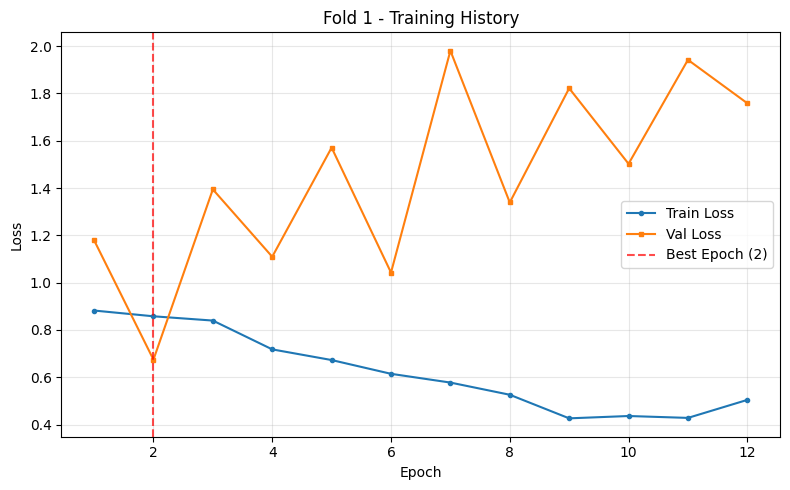


Threshold selected on Fold-1 Val: 0.3852
  Val Youden's J: 0.093
  Val Sensitivity: 0.700
  Val Specificity: 0.393

Fold 1 Test Results:
  AUROC: 0.3776
  AUPRC: 0.4301
  Threshold: 0.3852
  Sensitivity: 0.286
  Specificity: 0.548
  Accuracy: 0.417
  F1-score: 0.329
  Confusion Matrix: TP=12, TN=23, FP=19, FN=30

TRAINING FOLD 2

  Starting training for 50 epochs...
  Epoch 1/50 - Train Loss: 0.9558, Val Loss: 0.6014
  Epoch 2/50 - Train Loss: 0.7611, Val Loss: 0.8337
  Epoch 3/50 - Train Loss: 0.5567, Val Loss: 0.8095
  Epoch 4/50 - Train Loss: 0.4524, Val Loss: 1.2114
  Epoch 5/50 - Train Loss: 0.4555, Val Loss: 1.7166
  Epoch 6/50 - Train Loss: 0.4928, Val Loss: 2.6890
  Epoch 7/50 - Train Loss: 0.3848, Val Loss: 1.7927
  Epoch 8/50 - Train Loss: 0.3880, Val Loss: 2.7590
  Epoch 9/50 - Train Loss: 0.3839, Val Loss: 2.6376
  Epoch 10/50 - Train Loss: 0.3468, Val Loss: 2.6773
  🛑 Early stop at epoch 11 (best: 1) - Val Loss: 2.1887

✅ Fold 2 complete - Best Epoch: 1, Best Val Loss: 0.

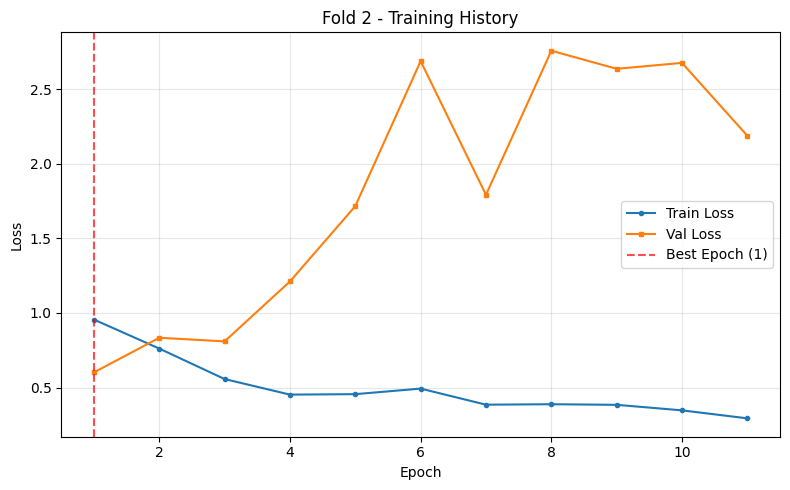


Threshold selected on Fold-2 Val: 0.5000
  Val Youden's J: 0.967
  Val Sensitivity: 1.000
  Val Specificity: 0.967

Fold 2 Test Results:
  AUROC: 0.2335
  AUPRC: 0.2323
  Threshold: 0.5000
  Sensitivity: 0.000
  Specificity: 0.944
  Accuracy: 0.624
  F1-score: 0.000
  Confusion Matrix: TP=0, TN=68, FP=4, FN=37

TRAINING FOLD 3

  Starting training for 50 epochs...
  Epoch 1/50 - Train Loss: 0.9740, Val Loss: 0.9947
  Epoch 2/50 - Train Loss: 0.8656, Val Loss: 1.2390
  Epoch 3/50 - Train Loss: 0.7498, Val Loss: 1.0554
  Epoch 4/50 - Train Loss: 0.6791, Val Loss: 1.1423
  Epoch 5/50 - Train Loss: 0.5832, Val Loss: 1.2213
  Epoch 6/50 - Train Loss: 0.5416, Val Loss: 1.2103
  Epoch 7/50 - Train Loss: 0.4526, Val Loss: 1.2238
  Epoch 8/50 - Train Loss: 0.4375, Val Loss: 1.3905
  Epoch 9/50 - Train Loss: 0.3860, Val Loss: 1.4224
  Epoch 10/50 - Train Loss: 0.4187, Val Loss: 1.5136
  🛑 Early stop at epoch 11 (best: 1) - Val Loss: 1.5300

✅ Fold 3 complete - Best Epoch: 1, Best Val Loss: 0.99

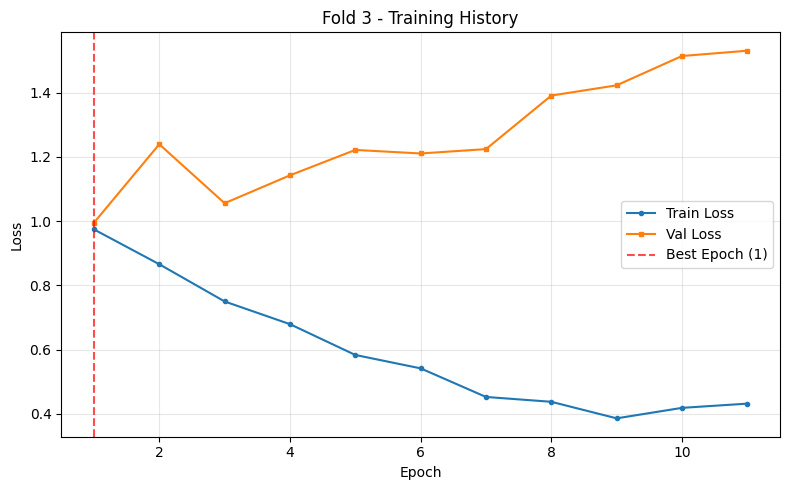


Threshold selected on Fold-3 Val: 0.5501
  Val Youden's J: 0.067
  Val Sensitivity: 0.974
  Val Specificity: 0.094

Fold 3 Test Results:
  AUROC: 0.7037
  AUPRC: 0.3117
  Threshold: 0.5501
  Sensitivity: 1.000
  Specificity: 0.033
  Accuracy: 0.171
  F1-score: 0.256
  Confusion Matrix: TP=20, TN=4, FP=116, FN=0

TRAINING FOLD 4

  Starting training for 50 epochs...
  Epoch 1/50 - Train Loss: 0.9666, Val Loss: 1.4493
  Epoch 2/50 - Train Loss: 0.8526, Val Loss: 1.2852
  Epoch 3/50 - Train Loss: 0.7701, Val Loss: 1.0053
  Epoch 4/50 - Train Loss: 0.6886, Val Loss: 1.0181
  Epoch 5/50 - Train Loss: 0.5969, Val Loss: 0.9976
  Epoch 6/50 - Train Loss: 0.5919, Val Loss: 1.0624
  Epoch 7/50 - Train Loss: 0.5507, Val Loss: 0.9454
  Epoch 8/50 - Train Loss: 0.5164, Val Loss: 0.9225
  Epoch 9/50 - Train Loss: 0.4796, Val Loss: 0.7451
  Epoch 10/50 - Train Loss: 0.4812, Val Loss: 1.1569
  Epoch 11/50 - Train Loss: 0.4405, Val Loss: 1.0394
  Epoch 12/50 - Train Loss: 0.3922, Val Loss: 1.5474
  Ep

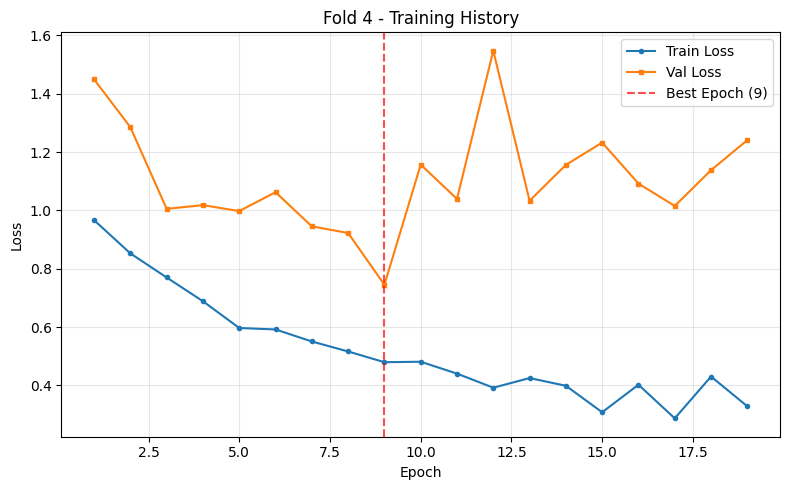


Threshold selected on Fold-4 Val: 0.3171
  Val Youden's J: 0.527
  Val Sensitivity: 0.900
  Val Specificity: 0.627

Fold 4 Test Results:
  AUROC: 0.7360
  AUPRC: 0.4271
  Threshold: 0.3171
  Sensitivity: 0.800
  Specificity: 0.580
  Accuracy: 0.600
  F1-score: 0.267
  Confusion Matrix: TP=4, TN=29, FP=21, FN=1

TRAINING FOLD 5

  Starting training for 50 epochs...
  Epoch 1/50 - Train Loss: 0.9443, Val Loss: 0.7891
  Epoch 2/50 - Train Loss: 0.7604, Val Loss: 0.9600
  Epoch 3/50 - Train Loss: 0.6432, Val Loss: 1.4754
  Epoch 4/50 - Train Loss: 0.4876, Val Loss: 1.2499
  Epoch 5/50 - Train Loss: 0.5144, Val Loss: 1.2712
  Epoch 6/50 - Train Loss: 0.3549, Val Loss: 1.0160
  Epoch 7/50 - Train Loss: 0.3728, Val Loss: 1.2350
  Epoch 8/50 - Train Loss: 0.3259, Val Loss: 1.2003
  Epoch 9/50 - Train Loss: 0.3981, Val Loss: 1.0780
  Epoch 10/50 - Train Loss: 0.2806, Val Loss: 1.2375
  🛑 Early stop at epoch 11 (best: 1) - Val Loss: 1.3516

✅ Fold 5 complete - Best Epoch: 1, Best Val Loss: 0.78

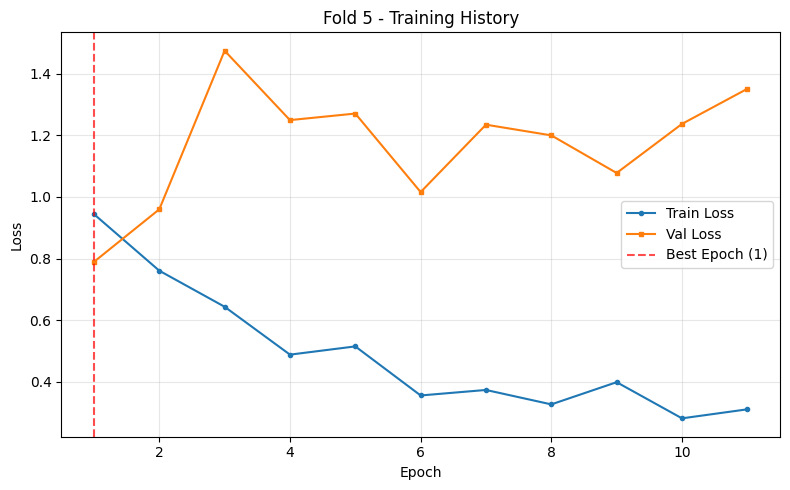


Threshold selected on Fold-5 Val: 0.2691
  Val Youden's J: 0.022
  Val Sensitivity: 1.000
  Val Specificity: 0.022

Fold 5 Test Results:
  AUROC: 0.5425
  AUPRC: 0.7507
  Threshold: 0.2691
  Sensitivity: 0.867
  Specificity: 0.146
  Accuracy: 0.629
  F1-score: 0.758
  Confusion Matrix: TP=72, TN=6, FP=35, FN=11

✅ ALL 5 FOLDS COMPLETED



In [9]:
# Main Training & Evaluation Loop (5 Folds)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# Store results
all_runs_results = []
trained_models = []

# Iterate through folds
for run_info in split_info["runs"]:
    run_idx = run_info["run"]
    print(f"\n{'='*60}")
    print(f"TRAINING FOLD {run_idx}")
    print(f"{'='*60}\n")

    # Initialize model
    model = TB_CNN(num_classes=1, channels=config.channels).to(device)
    
    # Train on fold-specific train/val
    model, history, best_epoch, best_val_loss = train_model(
        model=model,
        df_train=run_info["df_train"],
        df_val=run_info["df_val"],
        config=config,
        device=device
    )

    print(f"\n✅ Fold {run_idx} complete - Best Epoch: {best_epoch}, Best Val Loss: {best_val_loss:.4f}")

    # Plot loss curve
    plot_loss_curve(history, best_epoch, title=f"Fold {run_idx} - Training History")

    # Evaluate on validation set (for threshold selection)
    val_dataset = CustomImageDataset(
        run_info["df_val"],
        transform=config.val_transform,
        channels=config.channels
    )
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

    model.eval()
    val_scores = []
    val_true = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            scores = torch.sigmoid(outputs).cpu().numpy().flatten()
            val_scores.extend(scores)
            val_true.extend(labels.numpy())

    val_scores = np.array(val_scores)
    val_true = np.array(val_true)

    # Find threshold on fold validation set by Youden's J
    threshold_selector = ThresholdSelector()
    threshold, thr_metrics = threshold_selector.find_threshold(val_true, val_scores)

    print(f"\nThreshold selected on Fold-{run_idx} Val: {threshold:.4f}")
    print(f"  Val Youden's J: {thr_metrics['youden_j']:.3f}")
    print(f"  Val Sensitivity: {thr_metrics['sensitivity']:.3f}")
    print(f"  Val Specificity: {thr_metrics['specificity']:.3f}")

    # Evaluate on fold-specific test set
    test_dataset = CustomImageDataset(
        run_info["df_test"],
        transform=config.val_transform,
        channels=config.channels
    )
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)

    model.eval()
    test_scores = []
    test_true = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            scores = torch.sigmoid(outputs).cpu().numpy().flatten()
            test_scores.extend(scores)
            test_true.extend(labels.numpy())

    test_scores = np.array(test_scores)
    test_true = np.array(test_true)

    # Calculate metrics on fold test
    test_auroc = roc_auc_score(test_true, test_scores)
    test_auprc = average_precision_score(test_true, test_scores)

    # Apply threshold
    test_pred = (test_scores >= threshold).astype(int)
    tn = np.sum((test_true == 0) & (test_pred == 0))
    fp = np.sum((test_true == 0) & (test_pred == 1))
    fn = np.sum((test_true == 1) & (test_pred == 0))
    tp = np.sum((test_true == 1) & (test_pred == 1))

    test_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    test_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    test_accuracy = accuracy_score(test_true, test_pred)
    test_f1 = f1_score(test_true, test_pred, zero_division=0)

    print(f"\nFold {run_idx} Test Results:")
    print(f"  AUROC: {test_auroc:.4f}")
    print(f"  AUPRC: {test_auprc:.4f}")
    print(f"  Threshold: {threshold:.4f}")
    print(f"  Sensitivity: {test_sensitivity:.3f}")
    print(f"  Specificity: {test_specificity:.3f}")
    print(f"  Accuracy: {test_accuracy:.3f}")
    print(f"  F1-score: {test_f1:.3f}")
    print(f"  Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}")

    # Store results
    all_runs_results.append({
        "run": run_idx,
        "y_true": test_true,
        "scores": test_scores,
        "auroc": test_auroc,
        "auprc": test_auprc,
        "threshold": threshold,
        "sensitivity": test_sensitivity,
        "specificity": test_specificity,
        "accuracy": test_accuracy,
        "f1": test_f1,
        "confusion_matrix": {"TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn)},
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "n_train": len(run_info["df_train"]),
        "n_val": len(run_info["df_val"]),
        "n_test": len(run_info["df_test"]),
        "test_subjects": run_info["test_subjects"],
    })

    trained_models.append(model)

print(f"\n{'='*60}")
print("✅ ALL 5 FOLDS COMPLETED")
print(f"{'='*60}\n")

## Summary Table

In [10]:
# Summary Table

print("\n" + "="*80)
print("SUMMARY OF ALL 5 FOLDS (Fold-specific test performance)")
print("="*80 + "\n")

summary_data = []
for res in all_runs_results:
    summary_data.append({
        "Fold": res["run"],
        "AUROC": f"{res['auroc']:.4f}",
        "AUPRC": f"{res['auprc']:.4f}",
        "Sensitivity": f"{res['sensitivity']:.3f}",
        "Specificity": f"{res['specificity']:.3f}",
        "Accuracy": f"{res['accuracy']:.3f}",
        "F1-score": f"{res['f1']:.3f}",
        "Threshold": f"{res['threshold']:.4f}",
        "Best Epoch": res["best_epoch"],
        "n_train": res["n_train"],
        "n_val": res["n_val"],
        "n_test": res["n_test"],
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

# Calculate mean and std
aurocs = [res["auroc"] for res in all_runs_results]
auprcs = [res["auprc"] for res in all_runs_results]
sensitivities = [res["sensitivity"] for res in all_runs_results]
specificities = [res["specificity"] for res in all_runs_results]
accuracies = [res["accuracy"] for res in all_runs_results]
f1_scores = [res["f1"] for res in all_runs_results]

print("\n" + "-"*80)
print(f"Mean AUROC: {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")
print(f"Mean AUPRC: {np.mean(auprcs):.4f} ± {np.std(auprcs):.4f}")
print(f"Mean Sensitivity: {np.mean(sensitivities):.3f} ± {np.std(sensitivities):.3f}")
print(f"Mean Specificity: {np.mean(specificities):.3f} ± {np.std(specificities):.3f}")
print(f"Mean Accuracy: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Mean F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print("-"*80 + "\n")

# Save summary statistics to JSON for future comparison
summary_stats_json = {
    "model_type": "base_model_no_augmentation",
    "experiment_config": {
        "n_folds": config.n_runs,
        "inner_val_size": config.run_val_size,
        "epochs": config.epochs,
        "batch_size": config.batch_size,
        "learning_rate": config.learning_rate,
    },
    "folds_detail": [
        {
            "fold": res["run"],
            "auroc": float(res["auroc"]),
            "auprc": float(res["auprc"]),
            "sensitivity": float(res["sensitivity"]),
            "specificity": float(res["specificity"]),
            "accuracy": float(res["accuracy"]),
            "f1": float(res["f1"]),
            "threshold": float(res["threshold"]),
            "best_epoch": res["best_epoch"],
            "n_train": res["n_train"],
            "n_val": res["n_val"],
            "n_test": res["n_test"],
            "test_subjects": res["test_subjects"],
        }
        for res in all_runs_results
    ],
    "summary_statistics": {
        "auroc": {
            "mean": float(np.mean(aurocs)),
            "std": float(np.std(aurocs)),
            "values": [float(x) for x in aurocs]
        },
        "auprc": {
            "mean": float(np.mean(auprcs)),
            "std": float(np.std(auprcs)),
            "values": [float(x) for x in auprcs]
        },
        "sensitivity": {
            "mean": float(np.mean(sensitivities)),
            "std": float(np.std(sensitivities)),
            "values": [float(x) for x in sensitivities]
        },
        "specificity": {
            "mean": float(np.mean(specificities)),
            "std": float(np.std(specificities)),
            "values": [float(x) for x in specificities]
        },
        "accuracy": {
            "mean": float(np.mean(accuracies)),
            "std": float(np.std(accuracies)),
            "values": [float(x) for x in accuracies]
        },
        "f1": {
            "mean": float(np.mean(f1_scores)),
            "std": float(np.std(f1_scores)),
            "values": [float(x) for x in f1_scores]
        }
    }
}

# Save to file
summary_json_path = Path(config.output_dir) / "summary_statistics.json"
with open(summary_json_path, "w") as f:
    json.dump(summary_stats_json, f, indent=2)

print(f"✅ Summary statistics saved to: {summary_json_path}\n")


SUMMARY OF ALL 5 FOLDS (Fold-specific test performance)

 Fold  AUROC  AUPRC Sensitivity Specificity Accuracy F1-score Threshold  Best Epoch  n_train  n_val  n_test
    1 0.3776 0.4301       0.286       0.548    0.417    0.329    0.3852           2      258    170      84
    2 0.2335 0.2323       0.000       0.944    0.624    0.000    0.5000           1      252    151     109
    3 0.7037 0.3117       1.000       0.033    0.171    0.256    0.5501           1      302     70     140
    4 0.7360 0.4271       0.800       0.580    0.600    0.267    0.3171           9      386     71      55
    5 0.5425 0.7507       0.867       0.146    0.629    0.758    0.2691           1      278    110     124

--------------------------------------------------------------------------------
Mean AUROC: 0.5186 ± 0.1915
Mean AUPRC: 0.4304 ± 0.1766
Mean Sensitivity: 0.591 ± 0.382
Mean Specificity: 0.450 ± 0.328
Mean Accuracy: 0.488 ± 0.177
Mean F1-score: 0.322 ± 0.245
----------------------------------

## AUC Plot (Across 5 Folds)

Per-fold metrics:
  Fold 1: AUROC=0.3776, AUPRC=0.4301, ACC=0.417, F1=0.329
  Fold 2: AUROC=0.2335, AUPRC=0.2323, ACC=0.624, F1=0.000
  Fold 3: AUROC=0.7037, AUPRC=0.3117, ACC=0.171, F1=0.256
  Fold 4: AUROC=0.7360, AUPRC=0.4271, ACC=0.600, F1=0.267
  Fold 5: AUROC=0.5425, AUPRC=0.7507, ACC=0.629, F1=0.758


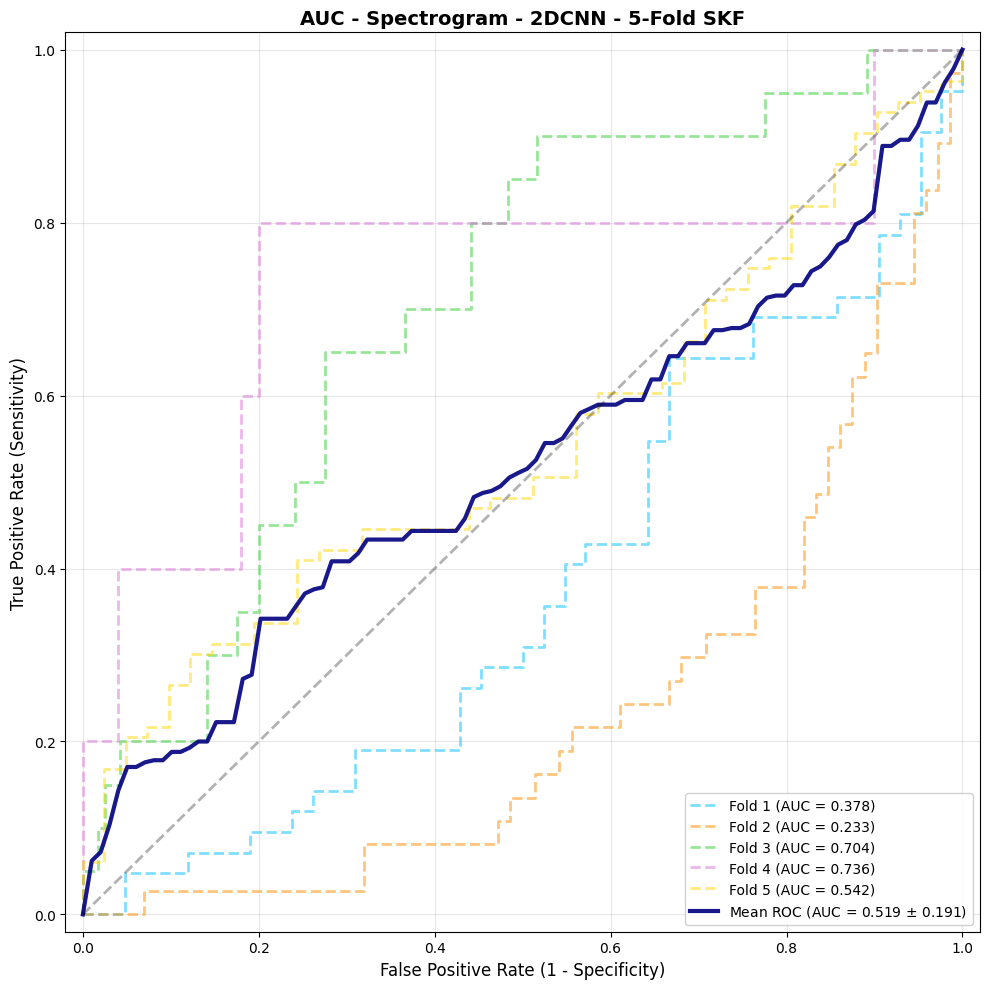

In [11]:
# Plot ROC Curves for All 5 Folds (no cross-fold ensemble)

print("Per-fold metrics:")
for res in all_runs_results:
    print(
        f"  Fold {res['run']}: "
        f"AUROC={res['auroc']:.4f}, "
        f"AUPRC={res['auprc']:.4f}, "
        f"ACC={res['accuracy']:.3f}, "
        f"F1={res['f1']:.3f}"
    )

plot_runs_roc_pr(
    runs_results=all_runs_results,
    title_prefix="Spectrogram - 2DCNN - 5-Fold SKF"
)

## Output

In [12]:
# Save Models & Results

output_dir = Path(config.output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

print(f"\n{'='*60}")
print(f"SAVING MODELS & RESULTS to {output_dir}")
print(f"{'='*60}\n")

# Save each fold's model
for i, model in enumerate(trained_models, start=1):
    model_path = output_dir / f"fold_{i}_best_model.pth"
    torch.save(model.state_dict(), model_path)
    print(f"✅ Saved: {model_path}")

# Save results as JSON
results_json = {
    "config": {
        "n_folds": config.n_runs,
        "inner_val_size": config.run_val_size,
        "epochs": config.epochs,
        "batch_size": config.batch_size,
        "learning_rate": config.learning_rate,
        "pos_weight": config.pos_weight,
        "early_stop_patience": config.early_stop_patience,
        "target_sensitivity": config.target_sensitivity,
        "seed": config.seed,
    },
    "folds": []
}

for res in all_runs_results:
    results_json["folds"].append({
        "fold": res["run"],
        "auroc": float(res["auroc"]),
        "auprc": float(res["auprc"]),
        "sensitivity": float(res["sensitivity"]),
        "specificity": float(res["specificity"]),
        "accuracy": float(res["accuracy"]),
        "f1": float(res["f1"]),
        "threshold": float(res["threshold"]),
        "confusion_matrix": res["confusion_matrix"],
        "best_epoch": res["best_epoch"],
        "best_val_loss": float(res["best_val_loss"]),
        "n_train": res["n_train"],
        "n_val": res["n_val"],
        "n_test": res["n_test"],
        "test_subjects": res["test_subjects"],
    })

results_json["summary"] = {
    "mean_auroc": float(np.mean(aurocs)),
    "std_auroc": float(np.std(aurocs)),
    "mean_auprc": float(np.mean(auprcs)),
    "std_auprc": float(np.std(auprcs)),
    "mean_sensitivity": float(np.mean(sensitivities)),
    "std_sensitivity": float(np.std(sensitivities)),
    "mean_specificity": float(np.mean(specificities)),
    "std_specificity": float(np.std(specificities)),
    "mean_accuracy": float(np.mean(accuracies)),
    "std_accuracy": float(np.std(accuracies)),
    "mean_f1": float(np.mean(f1_scores)),
    "std_f1": float(np.std(f1_scores)),
}

results_path = output_dir / "results.json"
with open(results_path, "w") as f:
    json.dump(results_json, f, indent=2)

print(f"✅ Saved: {results_path}")

# Save summary table as CSV
df_summary.to_csv(output_dir / "summary_table.csv", index=False)
print(f"✅ Saved: {output_dir / 'summary_table.csv'}")

print(f"\n{'='*60}")
print("✅ ALL FILES SAVED SUCCESSFULLY")
print(f"{'='*60}\n")


SAVING MODELS & RESULTS to output

✅ Saved: output\fold_1_best_model.pth
✅ Saved: output\fold_2_best_model.pth
✅ Saved: output\fold_3_best_model.pth
✅ Saved: output\fold_4_best_model.pth
✅ Saved: output\fold_5_best_model.pth
✅ Saved: output\results.json
✅ Saved: output\summary_table.csv

✅ ALL FILES SAVED SUCCESSFULLY



## Confusion matrix

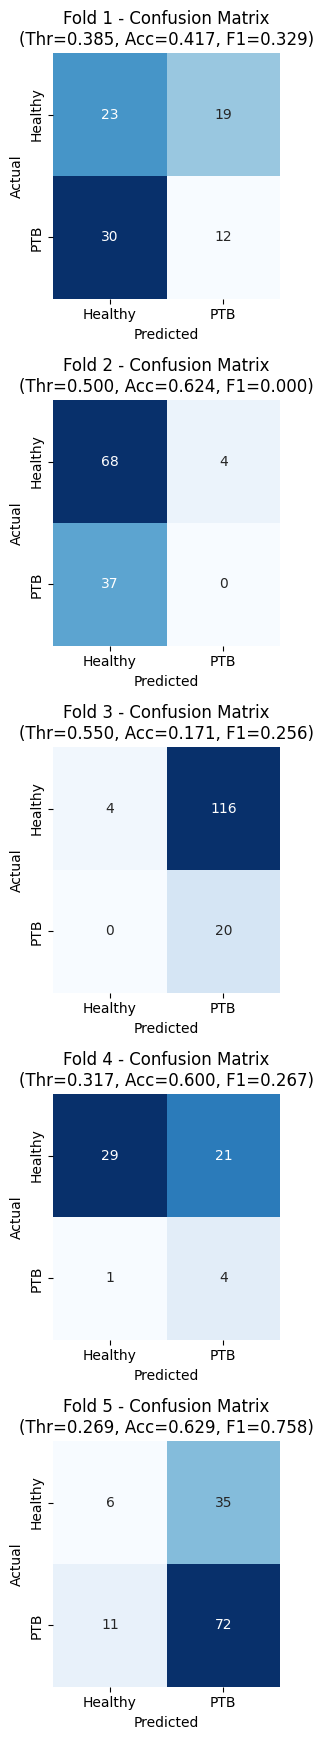

✅ Saved: output\confusion_matrices.png


In [13]:
# Plot Confusion Matrices for All Folds (vertical layout)

n_folds = len(all_runs_results)
fig, axes = plt.subplots(n_folds, 1, figsize=(3, 3.5 * n_folds))

if n_folds == 1:
    axes = [axes]

for i, res in enumerate(all_runs_results):
    cm = res["confusion_matrix"]
    cm_array = np.array([[cm["TN"], cm["FP"]], [cm["FN"], cm["TP"]]])
    
    ax = axes[i]
    sns.heatmap(
        cm_array,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Healthy", "PTB"],
        yticklabels=["Healthy", "PTB"],
        ax=ax,
        cbar=False
    )
    ax.set_title(
        f"Fold {res['run']} - Confusion Matrix\n"
        f"(Thr={res['threshold']:.3f}, Acc={res['accuracy']:.3f}, F1={res['f1']:.3f})"
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(output_dir / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Saved: {output_dir / 'confusion_matrices.png'}")

## Summary

In [14]:
# Final Summary Report

print("\n" + "="*80)
print("FINAL SUMMARY REPORT")
print("="*80 + "\n")

print("📊 CONFIGURATION:")
print(f"  Dataset: {config.data_dir}")
print(f"  Number of Folds: {config.n_runs}")
print(f"  Inner Val Size per Fold: {config.run_val_size * 100}% of train_val")
print(f"  Epochs: {config.epochs}")
print(f"  Batch Size: {config.batch_size}")
print(f"  Learning Rate: {config.learning_rate}")
print(f"  Pos Weight: {config.pos_weight}")
print(f"  Early Stop Patience: {config.early_stop_patience}")
print(f"  Target Sensitivity: {config.target_sensitivity}")
print(f"  Random Seed: {config.seed}\n")

print("📈 RESULTS (5-Fold fold-specific test):")
print(f"  Mean AUROC: {np.mean(aurocs):.4f} ± {np.std(aurocs):.4f}")
print(f"  Mean AUPRC: {np.mean(auprcs):.4f} ± {np.std(auprcs):.4f}")
print(f"  Mean Sensitivity: {np.mean(sensitivities):.3f} ± {np.std(sensitivities):.3f}")
print(f"  Mean Specificity: {np.mean(specificities):.3f} ± {np.std(specificities):.3f}")
print(f"  Mean Accuracy: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"  Mean F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}\n")

print("✅ STATUS:")
print(f"  Patient-level stratified splitting: ✓")
print(f"  No subject leakage (train/val/test): ✓")
print(f"  5 Independent folds: ✓")
print(f"  Fold-specific test evaluation: ✓")
print(f"  Early stopping with best state: ✓")
print(f"  Loss curves plotted per fold: ✓")
print(f"  ROC curves across folds: ✓")
print(f"  Detailed manifests generated: ✓")
print(f"  Models & results saved: ✓\n")

print("="*80)
print("🎉 EXPERIMENT COMPLETE!")
print("="*80 + "\n")

print(f"All outputs saved to: {output_dir.resolve()}")


FINAL SUMMARY REPORT

📊 CONFIGURATION:
  Dataset: ../../Data/spec_overall/
  Number of Folds: 5
  Inner Val Size per Fold: 25.0% of train_val
  Epochs: 50
  Batch Size: 8
  Learning Rate: 0.0001
  Pos Weight: 2.0
  Early Stop Patience: 10
  Target Sensitivity: 0.9
  Random Seed: 42

📈 RESULTS (5-Fold fold-specific test):
  Mean AUROC: 0.5186 ± 0.1915
  Mean AUPRC: 0.4304 ± 0.1766
  Mean Sensitivity: 0.591 ± 0.382
  Mean Specificity: 0.450 ± 0.328
  Mean Accuracy: 0.488 ± 0.177
  Mean F1-score: 0.322 ± 0.245

✅ STATUS:
  Patient-level stratified splitting: ✓
  No subject leakage (train/val/test): ✓
  5 Independent folds: ✓
  Fold-specific test evaluation: ✓
  Early stopping with best state: ✓
  Loss curves plotted per fold: ✓
  ROC curves across folds: ✓
  Detailed manifests generated: ✓
  Models & results saved: ✓

🎉 EXPERIMENT COMPLETE!

All outputs saved to: D:\TB-LATEST-CLONE\Tuberculosis_Classification_using_CoughSound\model\image_model\output
